In [27]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

In [97]:
# @nb.njit
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [98]:
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

S_left = 0.2  # Saturação injetada

In [99]:
# @nb.njit
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

# @nb.njit
def k_rw(S):
    Sn = S_n(S)
    return Sn**4

# @nb.njit
def k_rg(S):
    Sn = S_n(S)
    return (1 - Sn)**2

# @nb.njit
def f_w(S):
    krw = k_rw(S)
    krg = k_rg(S)
    return krw / (krw + (mu_w/mu_g) * krg)

# @nb.njit
def f(S):
    return u * f_w(S)

# @nb.njit
def rhs(t, y):
    F = np.empty(y.shape[0] + 1, dtype=np.float32)
    F[0] = f(S_left)
    F[1:] = f(y)

    return -(F[1:] - F[:-1]) / (phi * dx)
    

In [100]:
xs = np.linspace(dx/2, L - dx/2, Nx)
S0 = np.full(xs.shape[0], 0.9)
dt = 10.0
T_max = 15000

ts, Ss = ODE_system_solver(rhs, S0, 0, 15000, dt)

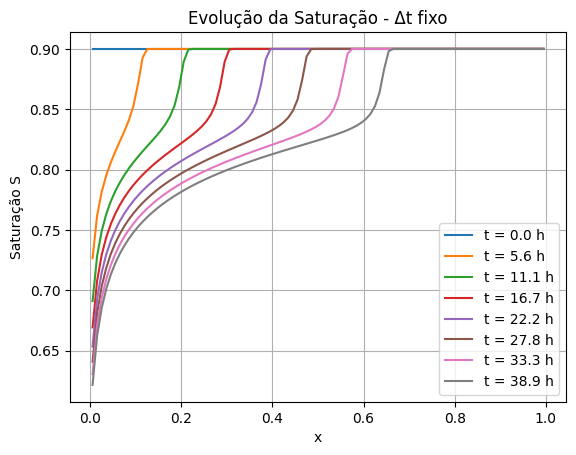

In [101]:
for t, S in zip(ts[::200], Ss[::200]):
    plt.plot(xs, S, label=f't = {t/360:.1f} h')

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
plt.legend()
plt.grid(True)
plt.show()

In [102]:
N = 700 # quantos pontos vamos ter a solução exta para treino
N_contorno = N // 10 # 10% pontos de contorno
N_inicial = N // 10 # 10% condição inicial

idxs_t = np.concat([
    np.random.randint(low=0, high=ts.shape[0], size=N_contorno), # pontos de contorno
    np.zeros(N_inicial, dtype=np.int32), # condição inicial (t = 0)
    np.random.randint(low=0, high=ts.shape[0], size=N - N_contorno - N_inicial),
])

idxs_x = np.concat([
    np.zeros(N_contorno, dtype=np.int32), # pontos de contorno (x = 0)
    np.random.randint(low=0, high=xs.shape[0], size=N_inicial), # condição inicial
    np.random.randint(low=0, high=xs.shape[0], size=N - N_contorno - N_inicial),
])

Xs = np.stack([ts[idxs_t], xs[idxs_x]], axis=1)
Ys = Ss[idxs_t, idxs_x]

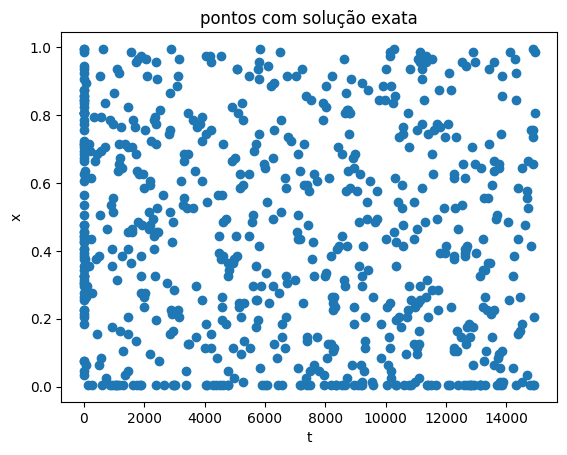

In [103]:
plt.scatter(Xs[:, 0], Xs[:, 1])
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.show()

In [104]:
lambda_1 = 1.0 # ?

In [116]:
def pinn_loss(X, y):

    dy_dt = torch.autograd.grad(y, X, grad_outputs=torch.ones_like(y), retain_graph=True, create_graph=True)[0][:, 0]
    
    f_val = f(y)
    df_dx = torch.autograd.grad(f_val, X, grad_outputs=torch.ones_like(y), retain_graph=True, create_graph=True)[0][:, 1:]
    
    L_f = torch.mean((phi * dy_dt + df_dx) ** 2)

    t = X[:, 0]
    x = X[:, 1:]
    
    # S(x, 0) = 0.2
    mask_inicial = (t == 0.0)
    if (mask_inicial.any()):
        L_b1 = torch.mean((y[mask_inicial] - S_left) ** 2)
    else:
        L_b1 = 0.0

    # S(0, t) = 1
    mask_contorno = (x == 0.0)
    if (mask_contorno.any()):
        L_b2 = torch.mean((y[mask_contorno] - 1.0) ** 2)
    else:
        L_b2 = 0.0

    L_PINN = L_f + lambda_1 * (L_b1 + L_b2)

    return L_PINN

In [106]:
batch_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [107]:
dataset = torch.utils.data.TensorDataset(torch.tensor(Xs, dtype=torch.float32), torch.tensor(Ys, dtype=torch.float32))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dataloader_iter = cycle(dataloader)

In [117]:
class Generator(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


G = Generator(2, 32).to(device)
D = Critic(32).to(device)

In [118]:
n_iter = 1000
lambda_gp = 10
n_critic = 5
lr = 1e-5
G_optimizer = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
D_optimizer = optim.Adam(D.parameters(), lr=lr * n_critic, betas=(0.0, 0.9))

In [120]:
for it in range(n_iter):

    x, y = next(dataloader_iter)
    x = x.to(device).requires_grad_(True)
    y = y.reshape(-1, 1).to(device)
    y_fake = G(x)


    # GRADIENT PENALTY DO DISCRIMINADOR
    eps = torch.rand(batch_size, 1, device=device)

    y_hat = eps * y + (1 - eps) * y_fake.detach() # para o gradiente não propagar para o gerador
    y_hat.requires_grad_(True)

    D_real = D(y)
    D_fake = D(y_fake.detach())
    D_y_hat = D(y_hat)

    grad = torch.autograd.grad(
        outputs=D_y_hat,
        inputs=y_hat,
        grad_outputs=torch.ones_like(D_y_hat),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grad_norm = grad.view(grad.size(0), -1).norm(2, dim=1) # flatten cada elemento do batch
    gp = ((grad_norm - 1) ** 2).mean()

    # TREINANDO O DISCRIMINADOR

    loss_D = D_fake.mean() - D_real.mean() + lambda_gp * gp

    D_optimizer.zero_grad()
    loss_D.backward()
    D_optimizer.step()

    # TREINANDO O GERADOR (GAN LOSS)
    
    loss_G = -D(y_fake).mean()

    G_optimizer.zero_grad()
    loss_G.backward()
    G_optimizer.step()

    # TREINANDO O GERADOR (PINN LOSS)

    x_pinn = x.clone().detach().requires_grad_(True)
    y_fake_pinn = G(x_pinn)
    L_PINN = pinn_loss(x_pinn, y_fake_pinn)

    # usa o mesmo otimizador. Deveria usar um diferente para L_PINN?
    G_optimizer.zero_grad()
    L_PINN.backward()
    G_optimizer.step()

    
    if (it + 1) % 100 == 0:
        print(f"Iter {it+1}: loss_D={loss_D.item():.4f}, loss_G={loss_G.item():.4f}, L_PINN={L_PINN.item():.4f}")

Iter 100: loss_D=6.0859, loss_G=0.0322, L_PINN=0.0475
Iter 200: loss_D=5.3376, loss_G=-0.0461, L_PINN=0.0340
Iter 300: loss_D=4.9558, loss_G=-0.1354, L_PINN=0.0243
Iter 400: loss_D=4.1030, loss_G=-0.2310, L_PINN=0.0173
Iter 500: loss_D=3.4194, loss_G=-0.3353, L_PINN=0.0123
Iter 600: loss_D=2.8905, loss_G=-0.4469, L_PINN=0.0088
Iter 700: loss_D=2.7859, loss_G=-0.5643, L_PINN=0.0064
Iter 800: loss_D=2.4798, loss_G=-0.6851, L_PINN=0.0050
Iter 900: loss_D=2.4311, loss_G=-0.8074, L_PINN=0.0042
Iter 1000: loss_D=2.3505, loss_G=-0.9244, L_PINN=0.0038


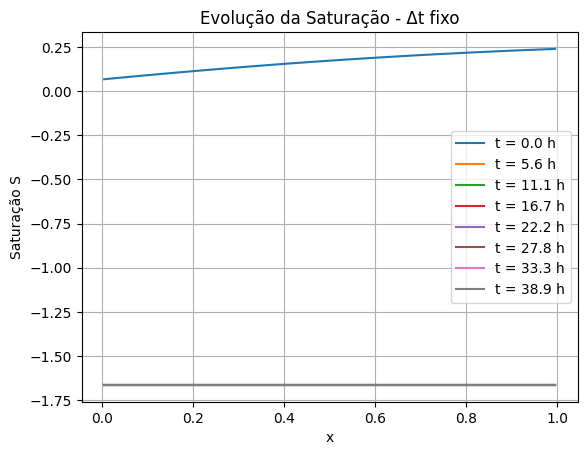

In [121]:
for t in ts[::200]:
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = G(X).detach().cpu().numpy()
    plt.plot(xs, S, label=f't = {t/360:.1f} h')

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
plt.legend()
plt.grid(True)
plt.show()